# Aula 2 - Quem Vive e quem Morre

In [26]:
# Instalação das bibliotecas necessárias
!pip install -q kaggle

## 1 - Ajuste de permissões

In [28]:
# insere o arquivo de secrets .sjon para acesso À base de dados
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"david064","key":"dd4dd35a53d29e7f0f2a3949a32f7240"}'}

In [29]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json # Set permissions

## 2 - Importação de Frameworks (bibliotecas)

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Configuração visual
sns.set(style="whitegrid")

## 3 - Carrega Base de dados

In [ ]:
import os
import zipfile

In [8]:
# Criar diretório para os dados do Kaggle, se não existir
if not os.path.exists('./kaggle_data'):
    os.makedirs('./kaggle_data')

In [9]:
!kaggle competitions download -c titanic -p ./kaggle_data

  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 89.4MB/s]


In [11]:
# Descompactar e carregar
zip_file = './kaggle_data/titanic.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
  zip_ref.extractall('./kaggle_data/titanic')

In [31]:
df = pd.read_csv('./kaggle_data/titanic/train.csv')
print(f"✅ Dados carregados! Dimensões: {df.shape}")
df.head().tail()

✅ Dados carregados! Dimensões: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.000,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.125,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.000,NaN,S
18,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.225,NaN,C


## Tratamento de dados

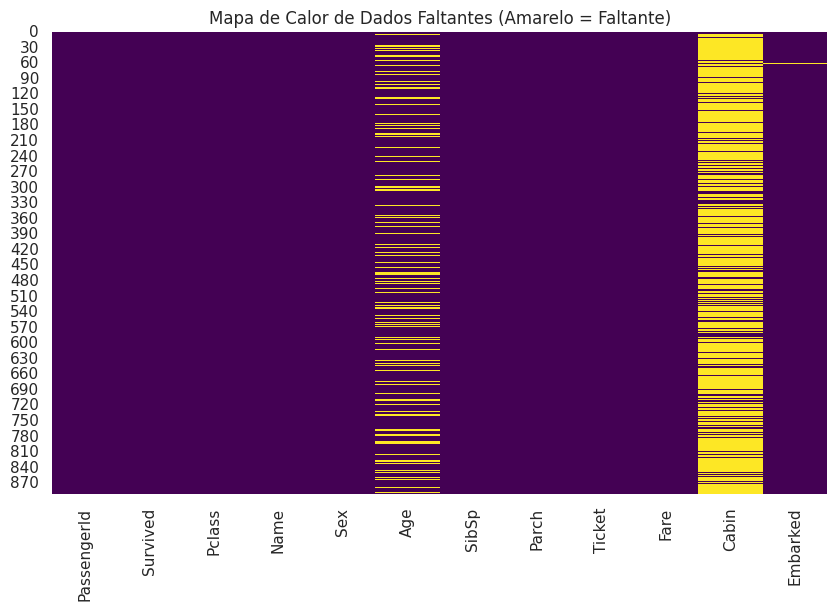

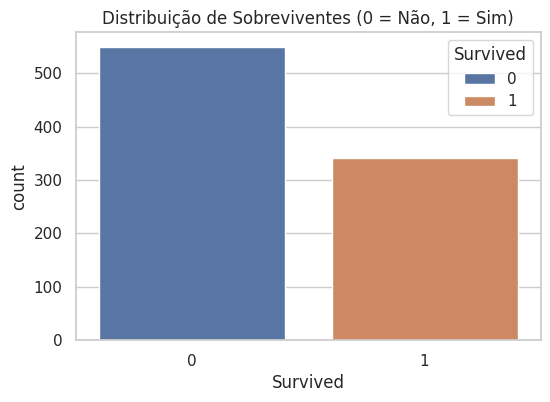

In [25]:
# Visualizando dados faltantes
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Dados Faltantes (Amarelo = Faltante)')
plt.show()

# Visualizando o balanceamento da variável alvo (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, hue = 'Survived')
plt.title('Distribuição de Sobreviventes (0 = Não, 1 = Sim)')
plt.show()

In [33]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

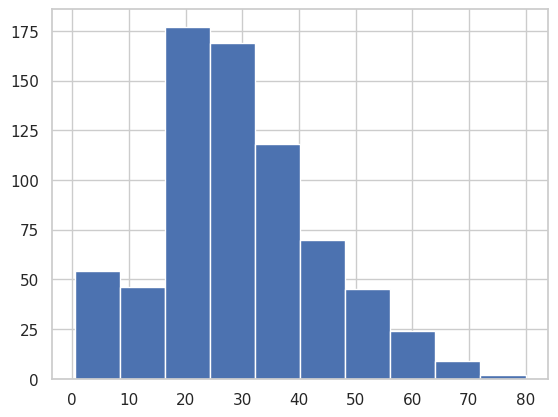

In [34]:
df['Age'].hist()

## Modelo Base line

In [32]:
# --- PREPARAÇÃO DO MODELO BASELINE ---

# Selecionar apenas numéricos e jogar fora o que é NaN
df_baseline = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].dropna()

X_base = df_baseline.drop('Survived', axis=1)
y_base = df_baseline['Survived']

# Divisão Treino/Teste
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

# Treino
model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train_b, y_train_b)

# Previsão
acc_base = accuracy_score(y_test_b, model_base.predict(X_test_b))
print(f"Acurácia do Modelo 'Preguiçoso': {acc_base:.2%}")

Acurácia do Modelo 'Preguiçoso': 69.93%


## Modelo Profissional

In [15]:
# --- PREPARAÇÃO DO MODELO PROFISSIONAL ---

# Separamos as Features (X) e o Alvo (y) do dataframe original
X = df.drop(['Survived', 'Name', 'Ticket', 'Cabin'], axis=1) # Removemos colunas irrelevantes
y = df['Survived']

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definindo colunas numéricas e categóricas
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Pclass'] # Pclass é numérico, mas age como categoria (1ª, 2ª, 3ª classe)

# 1. Pipeline para Numéricos: Preenche vazios com Mediana -> Padroniza a Escala
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline para Categóricos: Preenche vazios com Moda -> Transforma em Matriz de 0s e 1s
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Juntando tudo no Preprocessador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Pipeline Final: Pré-processamento -> Modelo
pipeline_pro = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Treinando o Pipeline Completo
pipeline_pro.fit(X_train, y_train)

# Avaliando
y_pred_pro = pipeline_pro.predict(X_test)
acc_pro = accuracy_score(y_test, y_pred_pro)

print(f"Acurácia do Modelo Profissional: {acc_pro:.2%}")

Acurácia do Modelo Profissional: 79.89%


## Métricas e resultados

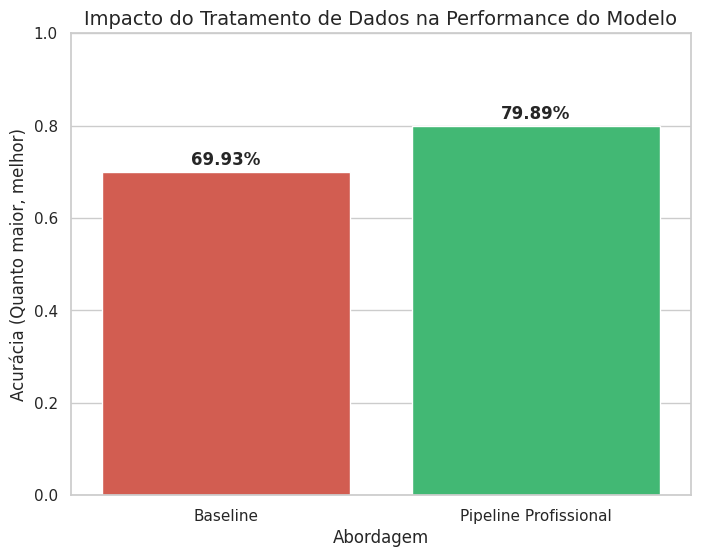

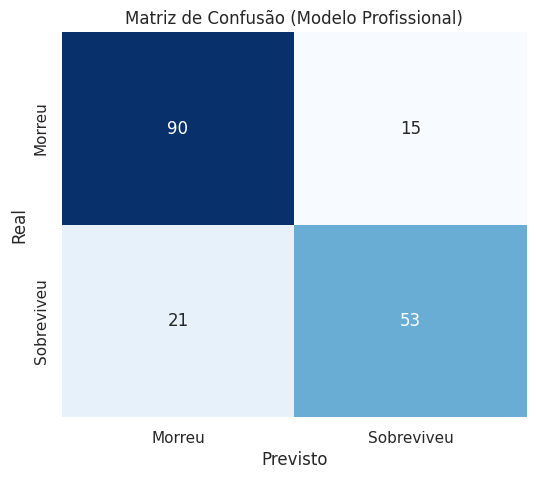

In [18]:
# Criando DataFrame para o gráfico comparativo de desempenho
resultados = pd.DataFrame({
    'Abordagem': ['Baseline', 'Pipeline Profissional'],
    'Acurácia': [acc_base, acc_pro]
})

# Gráfico de Comparação de Acurácia
plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(x='Abordagem', y='Acurácia', hue='Abordagem', data=resultados, palette=['#e74c3c', '#2ecc71'], legend=False)

# Adicionando os valores nas barras
for p in bar_plot.patches:
    bar_plot.annotate(f'{p.get_height():.2%}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha = 'center', va = 'center',
                      xytext = (0, 9),
                      textcoords = 'offset points',
                      fontweight='bold')

plt.ylim(0, 1)
plt.title('Impacto do Tratamento de Dados na Performance do Modelo', fontsize=14)
plt.ylabel('Acurácia (Quanto maior, melhor)')
plt.show()

# Matriz de Confusão do Modelo Profissional
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_pro)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Modelo Profissional)')
plt.xticks([0.5, 1.5], ['Morreu', 'Sobreviveu'])
plt.yticks([0.5, 1.5], ['Morreu', 'Sobreviveu'])
plt.show()

## Salva pipeline

In [21]:
import pickle

# Salvar o pipeline treinado
with open('pipeline_titanic.pkl', 'wb') as f:
    pickle.dump(pipeline_pro, f)

print("✅ Pipeline e modelo salvos com sucesso em 'pipeline_titanic.pkl'")

✅ Pipeline e modelo salvos com sucesso em 'pipeline_titanic.pkl'


In [22]:
# Carregar o pipeline treinado
with open('pipeline_titanic.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

print("✅ Pipeline carregado com sucesso!")
print(loaded_pipeline)

✅ Pipeline carregado com sucesso!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHot

## Extra: Black box

In [19]:
# 1. Acessando os passos dentro do nosso Pipeline
# Lembrem-se: demos nomes 'preprocessor' e 'classifier' na aula passada
model = pipeline_pro.named_steps['classifier']
preprocessor = pipeline_pro.named_steps['preprocessor']

# 2. Recuperando os nomes das colunas transformadas
# As numéricas continuam as mesmas
num_names = numeric_features

# As categóricas foram transformadas pelo OneHotEncoder
# Precisamos entrar no 'preprocessor', depois no 'cat' (transformer), depois no 'onehot'
cat_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Juntando tudo na ordem correta
feature_names = np.r_[num_names, cat_names]

# 3. Criando um DataFrame com os Coeficientes
coeficientes = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente (Log-Odds)': model.coef_[0]
})

# 4. Calculando o Odds Ratio (A "Chance Real")
# Exponencial do coeficiente remove o logaritmo
coeficientes['Odds Ratio (Chances)'] = np.exp(coeficientes['Coeficiente (Log-Odds)'])

# Ordenando pelo impacto (do mais positivo para o mais negativo)
coeficientes = coeficientes.sort_values(by='Coeficiente (Log-Odds)', ascending=False)

# Mostrando a tabela bonita
print("--- Tabela de Importância das Variáveis ---")
display(coeficientes)

--- Tabela de Importância das Variáveis ---


,Feature,Coeficiente (Log-Odds),Odds Ratio (Chances)
4,Sex_female,1.364873,3.915227
9,Pclass_1,0.764450,2.147812
10,Pclass_2,0.272380,1.313086
6,Embarked_C,0.240970,1.272483
3,Fare,0.186777,1.205359
7,Embarked_Q,0.079131,1.082346
2,Parch,-0.103198,0.901949
8,Embarked_S,-0.230692,0.793984
1,SibSp,-0.340804,0.711198
0,Age,-0.373004,0.688663


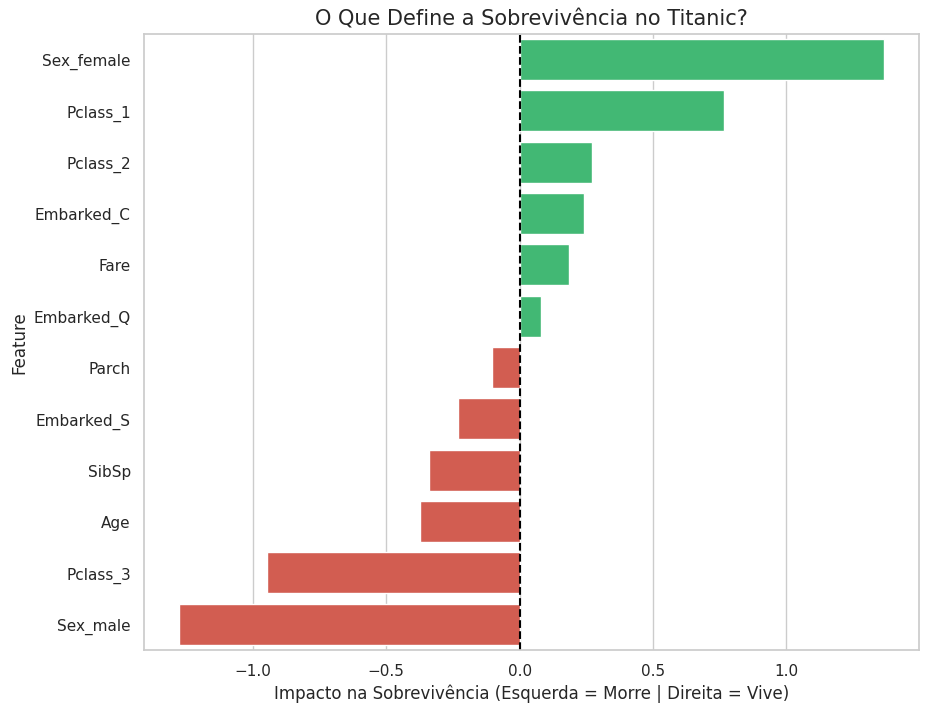

In [23]:
plt.figure(figsize=(10, 8))

# Criando cores baseadas no valor (Positivo=Verde/Azul, Negativo=Vermelho)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coeficientes['Coeficiente (Log-Odds)']]

sns.barplot(x='Coeficiente (Log-Odds)', y='Feature', hue='Feature', data=coeficientes, palette=colors, legend=False)

plt.title('O Que Define a Sobrevivência no Titanic?', fontsize=15)
plt.xlabel('Impacto na Sobrevivência (Esquerda = Morre | Direita = Vive)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Linha central no zero

plt.show()